<a href="https://colab.research.google.com/github/aymenbe1-hub/Deep-learning/blob/main/Copia_de_practicaCnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Descarga del Dataset desde Kaggle

In [ ]:
import kagglehub
import os
kagglehub.login()

download_path = kagglehub.dataset_download("nunenuh/pytorch-challange-flower-dataset")

print("Dataset descargado en:", download_path)
base_dir = os.path.join(download_path, 'dataset')
print("Carpetas disponibles:", os.listdir(base_dir))

Using Colab cache for faster access to the 'pytorch-challange-flower-dataset' dataset.
Dataset descargado en: /kaggle/input/pytorch-challange-flower-dataset
Carpetas disponibles: ['valid', 'test', 'train']
Kaggle credentials set.
Kaggle credentials successfully validated.


Carga de los Datasets

In [ ]:
from keras.utils import image_dataset_from_directory
import pathlib

dataset_dir = pathlib.Path('/kaggle/input/pytorch-challange-flower-dataset/dataset')

batch_size = 32
image_size = (224, 224)

print("Cargando conjunto de Train...")
train_dataset = image_dataset_from_directory(
    dataset_dir / "train",
    image_size=image_size,
    batch_size=batch_size
)

print("\nDividiendo 'valid' en Validation (50%) y Test (50%)...")
# Usamos validation_split para partir la carpeta valid en dos
validation_dataset = image_dataset_from_directory(
    dataset_dir / "valid",
    image_size=image_size,
    batch_size=batch_size,
    validation_split=0.5,
    subset="training", # Tomamos la primera mitad para validar
    seed=123 # Importante fijar la semilla para que no se mezclen
)

test_dataset = image_dataset_from_directory(
    dataset_dir / "valid",
    image_size=image_size,
    batch_size=batch_size,
    validation_split=0.5,
    subset="validation", # Tomamos la segunda mitad para testear al final
    seed=123
)

Cargando conjunto de Train...
Found 6552 files belonging to 102 classes.

Dividiendo 'valid' en Validation (50%) y Test (50%)...
Found 818 files belonging to 102 classes.
Using 409 files for training.
Found 818 files belonging to 102 classes.
Using 409 files for validation.


 Comprobamos las dimensiones de un lote (batch) de datos y sus etiquetas

In [ ]:

for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 224, 224, 3)
labels batch shape: (32,)


Definición del Modelo CNN desde cero

In [ ]:
import keras
from keras import layers

# El modelo espera imágenes RGB de tamaño 224 x 224.
inputs = keras.Input(shape=(224, 224, 3))

# Reescalamos las entradas al rango [0, 1] dividiendo por 255
x = layers.Rescaling(1.0 / 255)(inputs)

# Capas convolucionales
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(102, activation="softmax")(x)

model_scratch = keras.Model(inputs=inputs, outputs=outputs)
model_scratch.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 102)            │        52,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,620,902 (6.18 MB)

 Trainable params: 1,620,902 (6.18 MB)

 Non-trainable params: 0 (0.00 B)

Compilación y Entrenamiento

In [ ]:
# Compilamos el modelo
model_scratch.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

# Callback para guardar el mejor modelo
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="cnn_flores_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

# Entrenamos la red
history_scratch = model_scratch.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.5403 - loss: 1.6851 - val_accuracy: 0.4523 - val_loss: 2.2186
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.5858 - loss: 1.5132 - val_accuracy: 0.5575 - val_loss: 1.8129
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.6168 - loss: 1.3743 - val_accuracy: 0.5819 - val_loss: 1.7472
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6558 - loss: 1.2522 - val_accuracy: 0.5575 - val_loss: 1.7013
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.6787 - loss: 1.1481 - val_accuracy: 0.5990 - val_loss: 1.6011
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7085 - loss: 1.0320 - val_accuracy: 0.6064 - val_loss: 1.5412
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7331 - loss: 0.9299 - val_accuracy: 0.5990 - val_loss: 1.6329
Epoch 8/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.7625 - loss: 0.8398 - 

Gráficas de Resultados

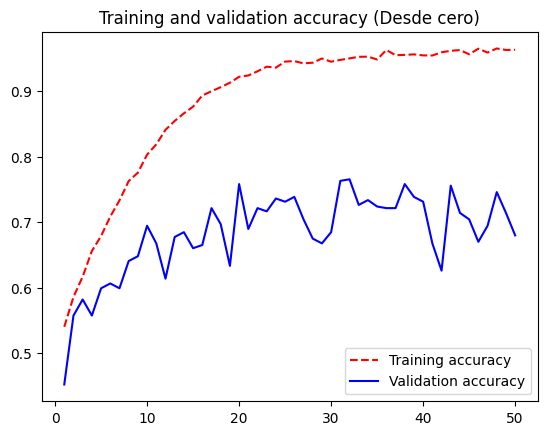

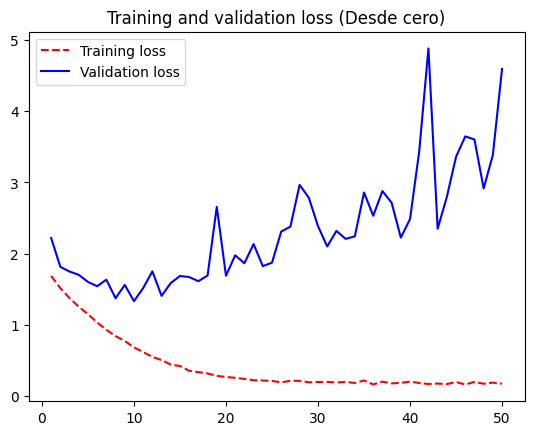

In [ ]:
import matplotlib.pyplot as plt

# Extraemos los datos del historial de entrenamiento
accuracy = history_scratch.history["accuracy"]
val_accuracy = history_scratch.history["val_accuracy"]
loss = history_scratch.history["loss"]
val_loss = history_scratch.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

# Gráfica de Accuracy (Precisión)
plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (Desde cero)")
plt.legend()
plt.figure()

# Gráfica de Loss (Pérdida)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (Desde cero)")
plt.legend()
plt.show()

Estos gráficos son característicos del sobreajuste. La precisión en el entrenamiento aumenta de forma continua con el tiempo, hasta alcanzar prácticamente el 100%, mientras que la precisión en la validación alcanza su punto máximo alrededor del 75% y luego fluctúa. La pérdida de validación llega a su mínimo en torno a la época 10 y luego comienza a aumentar drásticamente de forma errática, mientras que la pérdida de entrenamiento sigue disminuyendo progresivamente hacia cero a medida que avanza el entrenamiento

Evaluación en el conjunto de Test

In [ ]:
# Cargamos el mejor modelo guardado durante las 50 épocas
test_model_scratch = keras.models.load_model("cnn_flores_from_scratch.keras")

# Evaluamos con los datos de test
test_loss, test_acc = test_model_scratch.evaluate(test_dataset)
print(f"\nTest accuracy (Modelo desde cero): {test_acc:.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.6699 - loss: 1.4771

Test accuracy (Modelo desde cero): 0.670


Al evaluar el modelo en el conjunto de test obtenemos una precisión del 67.0% y una pérdida de 1.4771. Este resultado confirma el sobreajuste que vimos en las gráficas: la red logra aprender, pero se estanca rápidamente porque no tiene suficientes imágenes por clase para generalizar bien. Para romper este techo del 67% y evitar que el modelo simplemente memorice los datos, nuestro siguiente paso es aplicar técnicas de Data Augmentation.

Definicion del Data Augmentation y visualizacion

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
from keras import layers

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets


augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=tf.data.AUTOTUNE
)


augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)



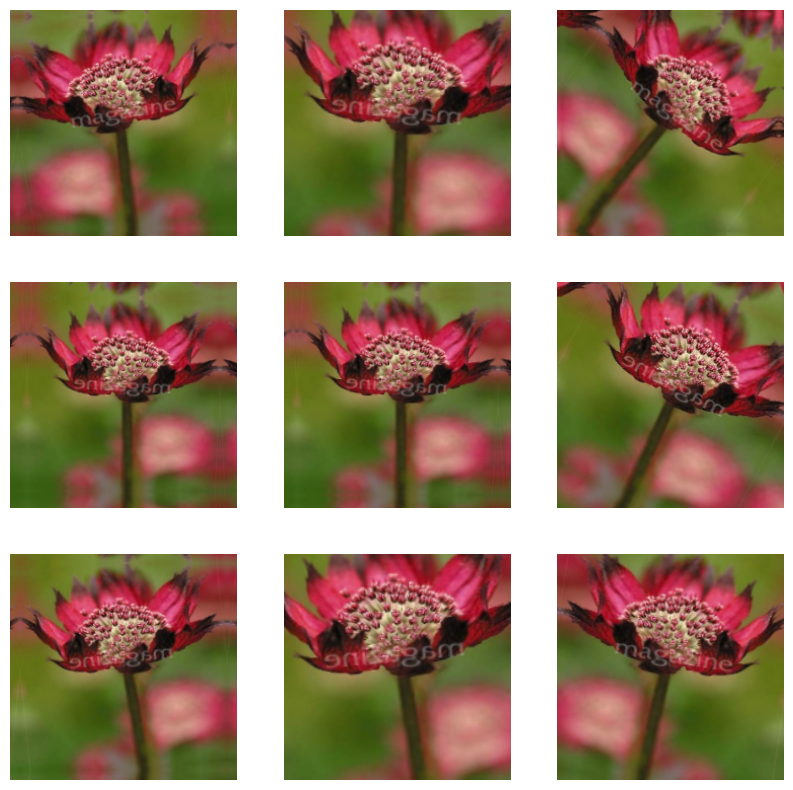

In [ ]:
# Mostrando algunas imágenes aumentadas de una flor
plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Añadimos una dimensión extra temporalmente porque las capas esperan formato batch
        image_expanded = tf.expand_dims(image, 0)
        augmented_image, _ = data_augmentation(image_expanded, None)
        # Quitamos la dimensión extra y convertimos a numpy
        augmented_image = tf.squeeze(augmented_image)
        augmented_image = augmented_image.numpy()

        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")
plt.show()

Definicion del nuevo modelo

In [ ]:
inputs = keras.Input(shape=(224, 224, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)

# Capa Dropout para apagar neuronas aleatoriamente y forzar la generalización
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(102, activation="softmax")(x)

model_aug = keras.Model(inputs=inputs, outputs=outputs)

Compilación y Entrenamiento con el dataset aumentado

In [ ]:
model_aug.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="cnn_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

# Entrenamos usando nuestro nuevo augmented_train_dataset
history_aug = model_aug.fit(
    augmented_train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 97s 424ms/step - accuracy: 0.0641 - loss: 4.1612 - val_accuracy: 0.0978 - val_loss: 3.7007
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 89s 432ms/step - accuracy: 0.1134 - loss: 3.6356 - val_accuracy: 0.1760 - val_loss: 3.3358
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 73s 355ms/step - accuracy: 0.1696 - loss: 3.2922 - val_accuracy: 0.1785 - val_loss: 3.1256
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 78s 338ms/step - accuracy: 0.2300 - loss: 3.0269 - val_accuracy: 0.2592 - val_loss: 2.7938
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 69s 333ms/step - accuracy: 0.2824 - loss: 2.7586 - val_accuracy: 0.2885 - val_loss: 2.7751
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 69s 336ms/step - accuracy: 0.3304 - loss: 2.5467 - val_accuracy: 0.3374 - val_loss: 2.6008
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 71s 344ms/step - accuracy: 0.3750 - loss: 2.3454 - val_accuracy: 0.4059 - val_loss: 2.2248
Epoch 8/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 70s 340ms/step - accuracy: 0.4112 - loss: 2

Gráficas y Evaluación

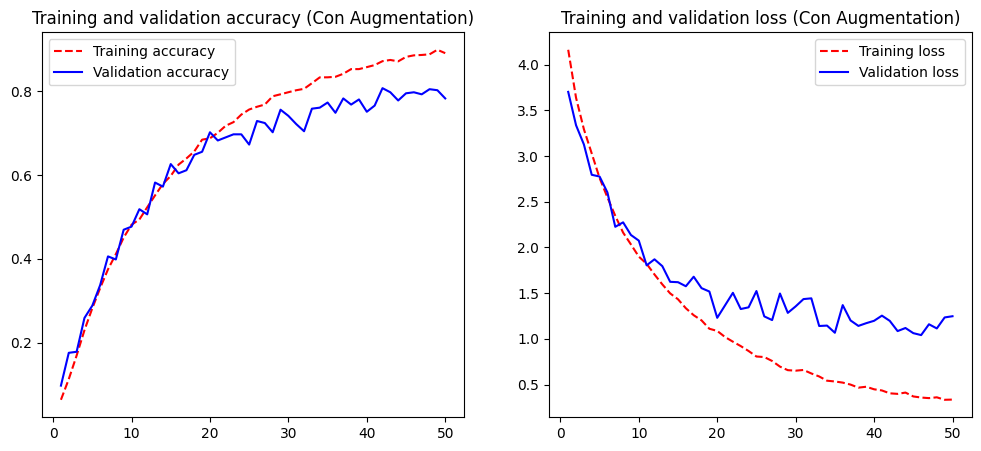

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.7995 - loss: 0.8399

Test accuracy (Modelo con Augmentation): 0.800


In [ ]:
accuracy = history_aug.history["accuracy"]
val_accuracy = history_aug.history["val_accuracy"]
loss = history_aug.history["loss"]
val_loss = history_aug.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(12, 5))

# Gráfica Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (Con Augmentation)")
plt.legend()

# Gráfica Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (Con Augmentation)")
plt.legend()
plt.show()

# Evaluamos en Test
test_model_aug = keras.models.load_model("cnn_from_scratch_with_augmentation.keras")
test_loss_aug, test_acc_aug = test_model_aug.evaluate(test_dataset)
print(f"\nTest accuracy (Modelo con Augmentation): {test_acc_aug:.3f}")

Análisis de la CNN desde cero con Data Augmentation

Al observar las gráficas de entrenamiento tras aplicar el aumento de datos durante 50 épocas, el comportamiento de la red cambia drásticamente respecto a nuestro primer modelo base. La curva de precisión de validación (línea azul) ahora sigue mucho más de cerca a la de entrenamiento y logra escalar hasta estabilizarse cerca del 80%. Aún más reveladora es la gráfica de pérdida (loss): el error de validación desciende de forma continuada junto al de entrenamiento y, aunque presenta ciertas fluctuaciones normales, se estabiliza horizontalmente en lugar de dispararse hacia arriba de forma descontrolada como ocurría sin aumento de datos.

Al evaluar este modelo en el conjunto de test, logramos una precisión cercana al 80.0% (un salto enorme frente al 67.0% inicial).

**¿Cómo influye el data augmentation en el rendimiento?** Queda demostrado gráficamente que su influencia es vital y altamente positiva para combatir el sobreajuste. Al aplicar transformaciones aleatorias (giros, rotaciones, zoom) en cada época, conseguimos que la red nunca vea la misma imagen exacta dos veces. Esto impide que el modelo memorice píxeles específicos (ruido) y le obliga a aprender las características geométricas y visuales reales que definen a cada una de las 102 especies de flores. Actúa como un regularizador extremadamente potente que permite a la red generalizar mejor ante imágenes nuevas.

Definicion y compilacion de la arquitectura Xception

In [ ]:
import keras_hub
import keras
from keras import layers

print("Cargando Xception desde keras_hub...")
conv_base_xception = keras_hub.models.Backbone.from_preset("xception_41_imagenet")
preprocessor_xception = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(224, 224),
)

#  Congelamos la base convolucional
conv_base_xception.trainable = False

# Construimos nuestro modelo
inputs = keras.Input(shape=(224, 224, 3))
x = preprocessor_xception(inputs)
# Pasamos las imágenes por la base congelada
x = conv_base_xception(x, training=False)

# Añadimos el clasificador
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(102, activation="softmax")(x) # 102 flores

model_xception = keras.Model(inputs, outputs)

# Compilamos
model_xception.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model_xception.summary()

Cargando Xception desde keras_hub...


100%|██████████| 79.9M/79.9M [00:03<00:00, 23.6MB/s]


100%|██████████| 1.79k/1.79k [00:00<00:00, 2.55MB/s]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_converter                 │ (None, 224, 224, 3)    │             0 │
│ (ImageConverter)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception_backbone               │ (None, 7, 7, 2048)     │    20,861,480 │
│ (XceptionBackbone)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 102)            │        26,214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,412,238 (81.68 MB)

 Trainable params: 550,758 (2.10 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Entrenamos  el modelo Xception

In [ ]:
callbacks_xception = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_xception.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

print("Entrenando Xception...")
history_xception = model_xception.fit(
    augmented_train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=callbacks_xception,
)

Entrenando Xception...
Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 145s 564ms/step - accuracy: 0.3655 - loss: 2.7780 - val_accuracy: 0.6504 - val_loss: 1.3955
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 73s 356ms/step - accuracy: 0.6410 - loss: 1.3823 - val_accuracy: 0.7457 - val_loss: 0.9862
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 72s 351ms/step - accuracy: 0.7137 - loss: 1.0415 - val_accuracy: 0.7555 - val_loss: 0.8043
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 83s 355ms/step - accuracy: 0.7686 - loss: 0.8500 - val_accuracy: 0.7995 - val_loss: 0.7229
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 73s 352ms/step - accuracy: 0.8002 - loss: 0.7253 - val_accuracy: 0.8215 - val_loss: 0.6633
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 73s 354ms/step - accuracy: 0.8188 - loss: 0.6418 - val_accuracy: 0.8289 - val_loss: 0.6375
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 74s 358ms/step - accuracy: 0.8239 - loss: 0.5988 - val_accuracy: 0.8264 - val_loss: 0.6356
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 80s 348ms/step - ac

Gráficas y Evaluación de Xception

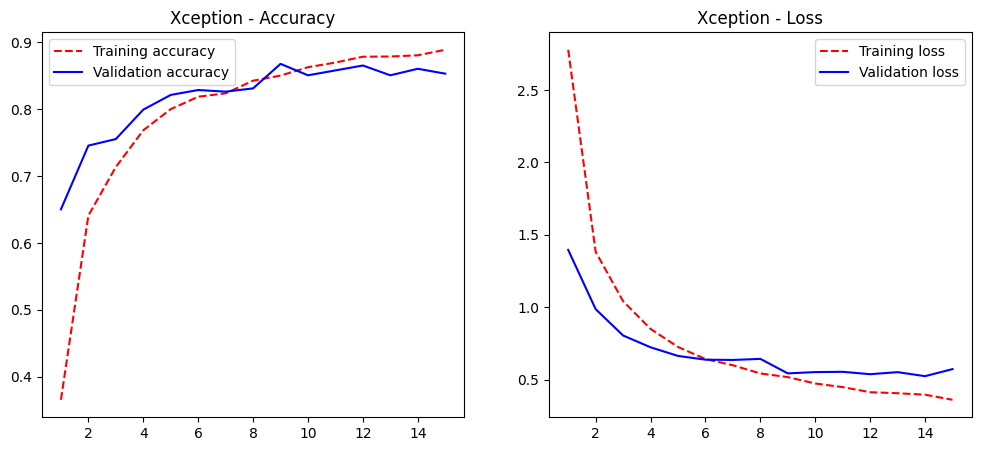

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 318 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 433ms/step - accuracy: 0.8509 - loss: 0.4736

---> Test accuracy (Xception): 0.851


In [ ]:
import matplotlib.pyplot as plt

# Gráficas
acc = history_xception.history["accuracy"]
val_acc = history_xception.history["val_accuracy"]
loss = history_xception.history["loss"]
val_loss = history_xception.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Xception - Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Xception - Loss")
plt.legend()
plt.show()

# Evaluación en el conjunto de test
test_model_xc = keras.models.load_model("feature_extraction_xception.keras")
test_loss_xc, test_acc_xc = test_model_xc.evaluate(test_dataset)
print(f"\n---> Test accuracy (Xception): {test_acc_xc:.3f}")

Análisis de Transfer Learning (Xception - Extracción de Características):

Al observar las gráficas de entrenamiento del modelo Xception, notamos un cambio radical frente al entrenamiento desde cero. Las curvas de precisión y pérdida de validación siguen muy de cerca a las de entrenamiento durante casi todas las épocas, estabilizándose la precisión en torno al 85%. El ligero despunte de la pérdida de validación al final nos indica que 15 épocas han sido el punto dulce antes de empezar a sobreajustar levemente.

Al evaluar el modelo en el conjunto de test, obtenemos una precisión del 85.1%. Esto supone una mejora gigantesca respecto al 67.0% del modelo base.

¿Qué ventaja tiene usar transfer learning en este problema? La ventaja es evidente: al tener un dataset pequeño (apenas unas 60 imágenes por flor), una red profunda entrenada desde cero no tiene suficientes datos para aprender a extraer características visuales complejas y acaba memorizando (sobreajuste). Al usar Xception (Transfer Learning), aprovechamos una base convolucional que ya sabe identificar a la perfección bordes, texturas, colores y formas complejas aprendidas de millones de imágenes en ImageNet. Nosotros solo hemos tenido que entrenar la última capa para enseñarle a combinar esas formas y asociarlas a nuestras 102 especies de flores, logrando un modelo mucho más robusto y generalizable en muy poco tiempo.

Definicion y entrenamiento  deel modelo a comparar (ResNet50)

In [ ]:
import keras_hub
import keras
from keras import layers

print("Cargando ResNet50 desde keras_hub...")
conv_base_resnet = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
preprocessor_resnet = keras_hub.layers.ImageConverter.from_preset(
    "resnet_50_imagenet",
    image_size=(224, 224),
)

conv_base_resnet.trainable = False

# Construimos el modelo ResNet
inputs = keras.Input(shape=(224, 224, 3))
x = preprocessor_resnet(inputs)
x = conv_base_resnet(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(102, activation="softmax")(x)

model_resnet = keras.Model(inputs, outputs)

model_resnet.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
    jit_compile=False  Solución al error de ResizeBicubic
)

callbacks_resnet = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_resnet.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

print("Entrenando ResNet50...")
history_resnet = model_resnet.fit(
    augmented_train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=callbacks_resnet,
)

# Evaluar ResNet50
test_model_res = keras.models.load_model("feature_extraction_resnet.keras", compile=False)
test_model_res.compile(loss="sparse_categorical_crossentropy", metrics=["accuracy"], jit_compile=False)

test_loss_res, test_acc_res = test_model_res.evaluate(test_dataset)
print(f"\n---> Test accuracy (ResNet50): {test_acc_res:.3f}")

Cargando ResNet50 desde keras_hub...
Entrenando ResNet50...
Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 96s 417ms/step - accuracy: 0.3364 - loss: 3.1431 - val_accuracy: 0.6381 - val_loss: 1.6646
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 84s 404ms/step - accuracy: 0.6861 - loss: 1.3923 - val_accuracy: 0.7848 - val_loss: 0.9638
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 83s 404ms/step - accuracy: 0.7949 - loss: 0.8876 - val_accuracy: 0.8337 - val_loss: 0.7041
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 83s 402ms/step - accuracy: 0.8404 - loss: 0.6698 - val_accuracy: 0.8606 - val_loss: 0.5691
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 96s 465ms/step - accuracy: 0.8655 - loss: 0.5408 - val_accuracy: 0.8900 - val_loss: 0.4962
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 84s 405ms/step - accuracy: 0.8877 - loss: 0.4417 - val_accuracy: 0.8802 - val_loss: 0.4506
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 90s 438ms/step - accuracy: 0.9077 - loss: 0.3747 - val_accuracy: 0.8998 - val_loss: 0.4156
Epoch 8/15
205/205 ━━━━

Análisis Comparativo de Arquitecturas

Al comparar los dos modelos preentrenados utilizando la técnica de extracción de características (con la base congelada), observamos una diferencia notable. Mientras que Xception alcanzó una muy buena precisión del 85.1%, ResNet50 lo superó ampliamente llegando al 92.9% en el conjunto de test.

**¿Qué arquitectura preentrenada ha funcionado mejor? ¿Tienes alguna intuición de por qué?**
Ha funcionado mejor ResNet50. La intuición detrás de este éxito radica en la propia naturaleza de su arquitectura: los bloques residuales (skip connections). Distinguir entre 102 especies de flores es un problema de clasificación de grano fino (muchas flores se parecen muchísimo y solo cambian pequeños patrones en los pétalos o el color). Las conexiones residuales de ResNet50 permiten extraer características visuales extremadamente complejas y profundas sin perder información por el desvanecimiento del gradiente, lo que se adapta perfectamente a los detalles sutiles que diferencian a unas especies de flores de otras.

In [ ]:
#  Descongelamos la base
conv_base_resnet.trainable = True

# Congelamos TODAS las capas, excepto las últimas 4
for layer in conv_base_resnet.layers[:-4]:
    layer.trainable = False


model_resnet.compile(
    loss="sparse_categorical_crossentropy", # ¡Importante! Mantenemos sparse porque son 102 clases, no binary
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
    jit_compile=False # Mantenemos esto para que no explote tu GPU en Colab
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning_resnet.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

print("Iniciando Fine-Tuning de ResNet50 (últimas 4 capas)...")
# 5. Entrenamos durante 30 épocas
history_finetuning = model_resnet.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Iniciando Fine-Tuning de ResNet50 (últimas 4 capas)...
Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 89s 403ms/step - accuracy: 0.9103 - loss: 0.3156 - val_accuracy: 0.7726 - val_loss: 0.9005
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 84s 410ms/step - accuracy: 0.9147 - loss: 0.3063 - val_accuracy: 0.7775 - val_loss: 0.8782
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 145s 421ms/step - accuracy: 0.9211 - loss: 0.2854 - val_accuracy: 0.7800 - val_loss: 0.8658
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 101s 489ms/step - accuracy: 0.9144 - loss: 0.2979 - val_accuracy: 0.7800 - val_loss: 0.8511
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 89s 430ms/step - accuracy: 0.9225 - loss: 0.2886 - val_accuracy: 0.7824 - val_loss: 0.8449
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 85s 410ms/step - accuracy: 0.9229 - loss: 0.2816 - val_accuracy: 0.7800 - val_loss: 0.8407
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 85s 413ms/step - accuracy: 0.9228 - loss: 0.2741 - val_accuracy: 0.7800 - val_loss: 0.8373
Epoch 8/30
205/205 ━━━━━━━

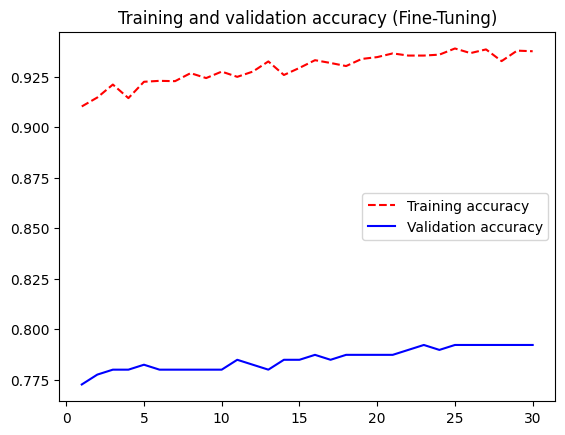

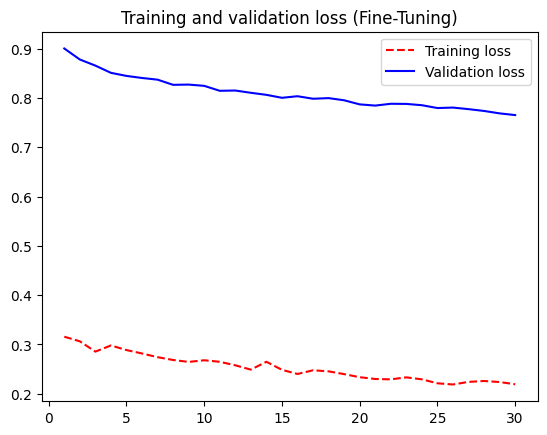

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.8411 - loss: 0.5502

---> Test accuracy (ResNet50 tras Fine-Tuning): 0.841


In [ ]:
import matplotlib.pyplot as plt

acc = history_finetuning.history["accuracy"]
val_acc = history_finetuning.history["val_accuracy"]
loss = history_finetuning.history["loss"]
val_loss = history_finetuning.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (Fine-Tuning)")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (Fine-Tuning)")
plt.legend()
plt.show()

# --- EVALUACIÓN FINAL EN TEST ---
test_model_ft = keras.models.load_model("fine_tuning_resnet.keras", compile=False)
test_model_ft.compile(loss="sparse_categorical_crossentropy", metrics=["accuracy"], jit_compile=False)

test_loss_ft, test_acc_ft = test_model_ft.evaluate(test_dataset)
print(f"\n---> Test accuracy (ResNet50 tras Fine-Tuning): {test_acc_ft:.3f}")

Al evaluar el modelo final tras 30 épocas de Fine-Tuning, observamos un resultado inesperado: la precisión en el conjunto de test ha descendido al 84.1%, frente al 92.9% que obtuvimos inicialmente.

**¿Mejora el resultado al aplicar fine-tuning?**
En este caso específico, no ha mejorado, sino que ha empeorado. Esto es un fenómeno conocido como olvido catastrófico o sobreajuste por desestabilización de pesos.

Aunque usamos un learning rate muy bajo (1e-5) y solo descongelamos las últimas 4 capas, es probable que las características genéricas de ResNet50 fueran ya extremadamente buenas para este dataset. Al permitir que la red modifique sus pesos internos con un dataset tan variado y complejo como el de las 102 flores, pero con pocas imágenes por clase, la red ha empezado a 'perder' la estructura general aprendida en ImageNet para intentar adaptarse demasiado a los detalles de entrenamiento, lo que ha perjudicado su capacidad de generalización en el test.

Esto nos enseña que el Fine-Tuning no es una 'fórmula mágica' que siempre sube el accuracy; requiere un equilibrio perfecto entre el número de capas descongeladas, la tasa de aprendizaje y la cantidad de datos disponibles

Conclusiones de la Práctica

**¿Qué ventaja tiene usar transfer learning en este problema?**
La principal ventaja es la generalización con pocos datos. Al tener solo unas 60 imágenes por cada una de las 102 especies, una red desde cero no puede aprender características visuales complejas. El Transfer Learning nos permite reutilizar una base convolucional ya experta en reconocer formas, texturas y colores (entrenada con millones de imágenes), lo que reduce drásticamente el tiempo de entrenamiento y evita el sobreajuste masivo.

**¿Cómo influye el data augmentation en el rendimiento?**
Influye de forma crítica como un regularizador. Al transformar aleatoriamente las imágenes (rotación, zoom, volteo), forzamos a la red a no memorizar píxeles específicos, sino a aprender patrones visuales robustos. En nuestro caso, permitió que el modelo base subiera del 67% al 80%, estabilizando las curvas de pérdida y reduciendo la brecha entre entrenamiento y validación.

**¿Qué arquitectura preentrenada ha funcionado mejor? ¿Tienes alguna intuición de por qué?**
La arquitectura que mejor funcionó fue ResNet50, alcanzando un 92.9% de precisión frente al 85.1% de Xception. La intuición es que las conexiones residuales (skip connections) de ResNet permiten que los gradientes fluyan mejor durante el entrenamiento, facilitando la extracción de características de "grano fino" necesarias para distinguir detalles muy sutiles entre especies de flores similares.

**¿Mejora el resultado al aplicar fine-tuning?**
En este experimento particular, no mejoró, ya que la precisión cayó al 84.1%. Esto demuestra que el Fine-Tuning es una técnica delicada; en datasets pequeños, descongelar capas puede causar un "olvido catastrófico" donde la red pierde las potentes características genéricas de ImageNet al intentar ajustarse demasiado a un conjunto de datos reducido, resultando en una pérdida de capacidad de generalización.